# Case Study

----

### Aims

The main objective of this case study was to implement a basic pipeline to: 

1. Generate representations of graph networks with differing node signal profiles
    - The GIN architecture was used for this
2. Compare those representations to discover clusters of similar graphs, or those most similar to a set of selected graphs
    - Cosine similarity was used for this, along with uMAP dimensionality reduction for visualisation
    - HDBScan was used for clustering as it is density-based, similar to uMAP

### Drug

The anti-malarial drug `mefloquine`, along with 4 other known anti-malarials for reference, were chosen for comparison with 500 randomly selected drugs. 

The graph topology (921 nodes and 8,738 edges) onto which the signal for each drug is overlayed doesn't change in each case.

Node signal here is from one timepoint only.

### Notebook

This notebook shows the analysis pipeline downstream from generating the context networks i.e. the 505 networks, each with drug-specific node signal integrated as the node attribute 'dexp' (differential expression).

Each graph has an associated drug ID (referred to as 'perturbagen ID'). This ID was integrated into the graph's filename.

<br>

----

# Packages

In [1]:
# General
from adjustText import adjust_text
import hdbscan
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import os
import pandas as pd
import pickle
import seaborn as sns
from tqdm import tqdm

# GIN
import torch
from torch.nn import Linear, ReLU, Sequential
import torch.nn.functional as F
from torch_geometric.nn import GINConv, global_add_pool
from sklearn.metrics.pairwise import cosine_similarity
from torch_geometric.utils import from_networkx

# uMAP
import umap.umap_ as umap

c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Directories

In [2]:
INPUT = 'D:/DDesktop/_work/data/canada/input/'
OUTPUT = 'D:/DDesktop/_work/data/canada/output/'

GRAPH = 'D:/DDesktop/_work/graphs/canada/'
CONTEXT = 'D:/DDesktop/_work/graphs/canada/context/'

# Functions

In [ ]:
def pickle_load(path: str, report: bool = False):
    '''
    Loads pickled data.
    '''

    with open(path, 'rb') as f:
        data = pickle.load(f)

    if report == True:
        if type(data) == nx.Graph:
            num_nodes = len(data.nodes)
            num_edges = len(data.edges)
            print('>> pickle_load')
            print(f'Pickled graph loaded w/ {num_nodes:,} nodes and {num_edges:,} edges')
            print()
        else:
            print('>> pickle_load')
            print(f'Pickled file loaded')
            print()

    return data

def pickle_save(path: str, data, report: bool = False):
    '''
    Pickles data.
    '''

    with open(path, 'wb') as f:
        pickle.dump(data, f)

    if report == True:
        if type(data) == nx.Graph:
            num_nodes = len(data.nodes)
            num_edges = len(data.edges)
            print('>> pickle_save')
            print(f'Graph w/ {num_nodes:,} nodes and {num_edges:,} edges pickled')
        else:
            print('>> pickle_save')
            print(f'Data pickled')
            print()


# 1. Analysis

In [4]:
# Load data
df_lincs_perturbagens = pickle_load(OUTPUT + 'df_lincs_perturbagens.pkl')

# Get anti-malarial perturbagen IDs
list_known_names = ['imatinib', 'pentoxifylline', 'mefloquine', 'rosiglitazone', 'imiquimod']
list_known_ids = [df_lincs_perturbagens['perturbagen_id'][df_lincs_perturbagens['perturbagen_name'] == name].values[0] for name in list_known_names if name in df_lincs_perturbagens['perturbagen_name'].values]

# Set mefloquine ID
mefloquine_id = 'BRD-K40645748'

# Show data
df_lincs_perturbagens.head()

,perturbagen_id,perturbagen_name
0,DMSO,DMSO
1,BRD-A03772856,BRD-A03772856
2,BRD-A19037878,trichostatin-a
3,BRD-A19500257,geldanamycin
4,BRD-A34037822,KUC107191N


## 1.1 Graph list

The network graphs saved as pickled (`.pkl`) object are converted to `torch_geometric` pyg objects to pass to the GIN.

In [5]:
# Initialise graph list
pyg_graphs = []

# Iterate through files
for graph in tqdm(os.listdir(CONTEXT), desc = 'Converting context graphs to PyG objects', total = len(os.listdir(CONTEXT))):
    
    # Get perturbagen id from filename
    perturbagen_id = graph.split('_')[1]
    
    # Load data
    G = pickle_load(CONTEXT + graph)
    # Iterate through nodes
    for node in G.nodes:
        # Assign the `dexp` attribute as `x`
        G.nodes[node]['x'] = [G.nodes[node]['dexp']]
    
    # Convert to PyG object
    pyg = from_networkx(G)
    pyg.x = pyg.x.float()
    # Add perturbagen ID as name
    pyg.name = f'{perturbagen_id}'
    pyg_graphs.append(pyg)

Converting context graphs to PyG objects: 100%|██████████| 505/505 [02:28<00:00,  3.39it/s]


## 1.2 GIN

A GIN is setup using recommended/default settings, and used to generate embeddings.

In [69]:
# Define untrained GIN encoder
class GINEncoder(torch.nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        nn1 = Sequential(Linear(1, hidden_dim), ReLU(), Linear(hidden_dim, hidden_dim))
        nn2 = Sequential(Linear(hidden_dim, hidden_dim), ReLU(), Linear(hidden_dim, hidden_dim))
        self.conv1 = GINConv(nn1)
        self.conv2 = GINConv(nn2)
        self.lin = Linear(hidden_dim, hidden_dim)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = global_add_pool(x, batch)
        return self.lin(x)

print('Untrained GIN encoder complete')

# Instantiate model
encoder = GINEncoder()
encoder.eval()

print('Model instantiated')

# Generate embeddings w/o training
embeddings = []
with torch.no_grad():
    for graph in tqdm(pyg_graphs, desc = 'Generating embeddings', total = len(pyg_graphs)):
        batch = torch.zeros(graph.x.size(0), dtype=torch.long)
        emb = encoder(graph.x, graph.edge_index, batch)
        embeddings.append(emb.squeeze())

# Extract embedding matrix
embedding_matrix = torch.stack(embeddings).numpy()

Untrained GIN encoder complete
Model instantiated


Generating embeddings: 100%|██████████| 505/505 [00:00<00:00, 995.25it/s] 


## 1.3 Cosine Similarity

The embedding matrix was 'centered' before normalisation by subtracting the mean vector value from said matrix. This allowed for better separation among embedding vectors.

For each of the 5 known anti-malarials (`list_known_names`), cosine similarity to all other graph embedding vectors was calculated. This allowed for extraction of the $n$ most similar graphs to each anti-malarial.

In [70]:
# Subtract mean vector and center matrix
centered = embedding_matrix - embedding_matrix.mean(axis=0, keepdims=True)
# Normalise centered values
centered = centered / np.linalg.norm(centered, axis=1, keepdims=True)

# Initialise dataframe
df_centered = pd.DataFrame()

# Iterate through IDs
for id in list_known_ids:
    # Find index in pyg_graphs
    ref_idx = next(i for i, g in enumerate(pyg_graphs) if g.name == id)
    
    # Calculate cosine similarity
    sims = cosine_similarity([centered[ref_idx]], centered)[0]
    # Sort values 
    sims_sort = np.sort(sims)[::-1]
    # Sort by closest similarity
    similarity = sims.argsort()[::-1]
    # Get graph IDs
    similar_ids = [pyg_graphs[i].name for i in similarity]
    # Convert to dataframe
    df_id = pd.DataFrame(similar_ids, columns = ['perturbagen_id'])
    # Merge
    df_id = pd.merge(df_id, df_lincs_perturbagens, on = 'perturbagen_id', how = 'left')
    # Add column
    df_id['value'] = sims_sort
    # Add ref column
    df_id['ref_id'] = id
    df_id['ref_name'] = df_lincs_perturbagens['perturbagen_name'][df_lincs_perturbagens['perturbagen_id'] == id].values[0]
    # Concatenate
    df_centered = pd.concat([df_centered, df_id])

df_centered.head()

,perturbagen_id,perturbagen_name,value,ref_id,ref_name
0,BRD-K92723993,imatinib,1.000000,BRD-K92723993,imatinib
1,BRD-K40645748,mefloquine,0.989909,BRD-K92723993,imatinib
2,BRD-A69917777,aminopentamide,0.986226,BRD-K92723993,imatinib
3,BRD-K15409150,penfluridol,0.986195,BRD-K92723993,imatinib
4,BRD-A58157837,butabindide,0.984417,BRD-K92723993,imatinib


## 1.4 uMAP

Dimensionality reduction was used to visualise centered and normalised embedding vectors in a scatterplot.

Mefloquine is highlighted in red, the other 4 anti-malarials are highlighted in orange.

The 10 most similar drugs to each of the anti-malarials are labelled in black.

In [71]:
# uMAP
reducer = umap.UMAP(n_components=2, random_state=42, spread = 1)
embedding_2d = reducer.fit_transform(centered)
graph_ids = [g.name for g in pyg_graphs]

# Convert to dataframe
df_plot = pd.DataFrame(embedding_2d, columns = ['x', 'y'])
df_plot['perturbagen_id'] = graph_ids

# Merge
df_plot = pd.merge(df_plot, df_lincs_perturbagens, on = 'perturbagen_id', how = 'left')
# Show data
df_plot.head()

c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,x,y,perturbagen_id,perturbagen_name
0,10.606697,10.485382,BRD-A00474148,BRD-A00474148
1,12.513202,5.948812,BRD-A01593789,chlormadinone-acetate
2,7.809190,14.265384,BRD-A01826957,xanthinol
3,12.502592,5.497871,BRD-A02006392,nitrendipine
4,8.276833,14.160019,BRD-A04706586,bucladesine


C:\Users\roman\AppData\Local\Temp\ipykernel_33208\3175959948.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_slice.sort_values(by = 'value', ascending = False, inplace = True)


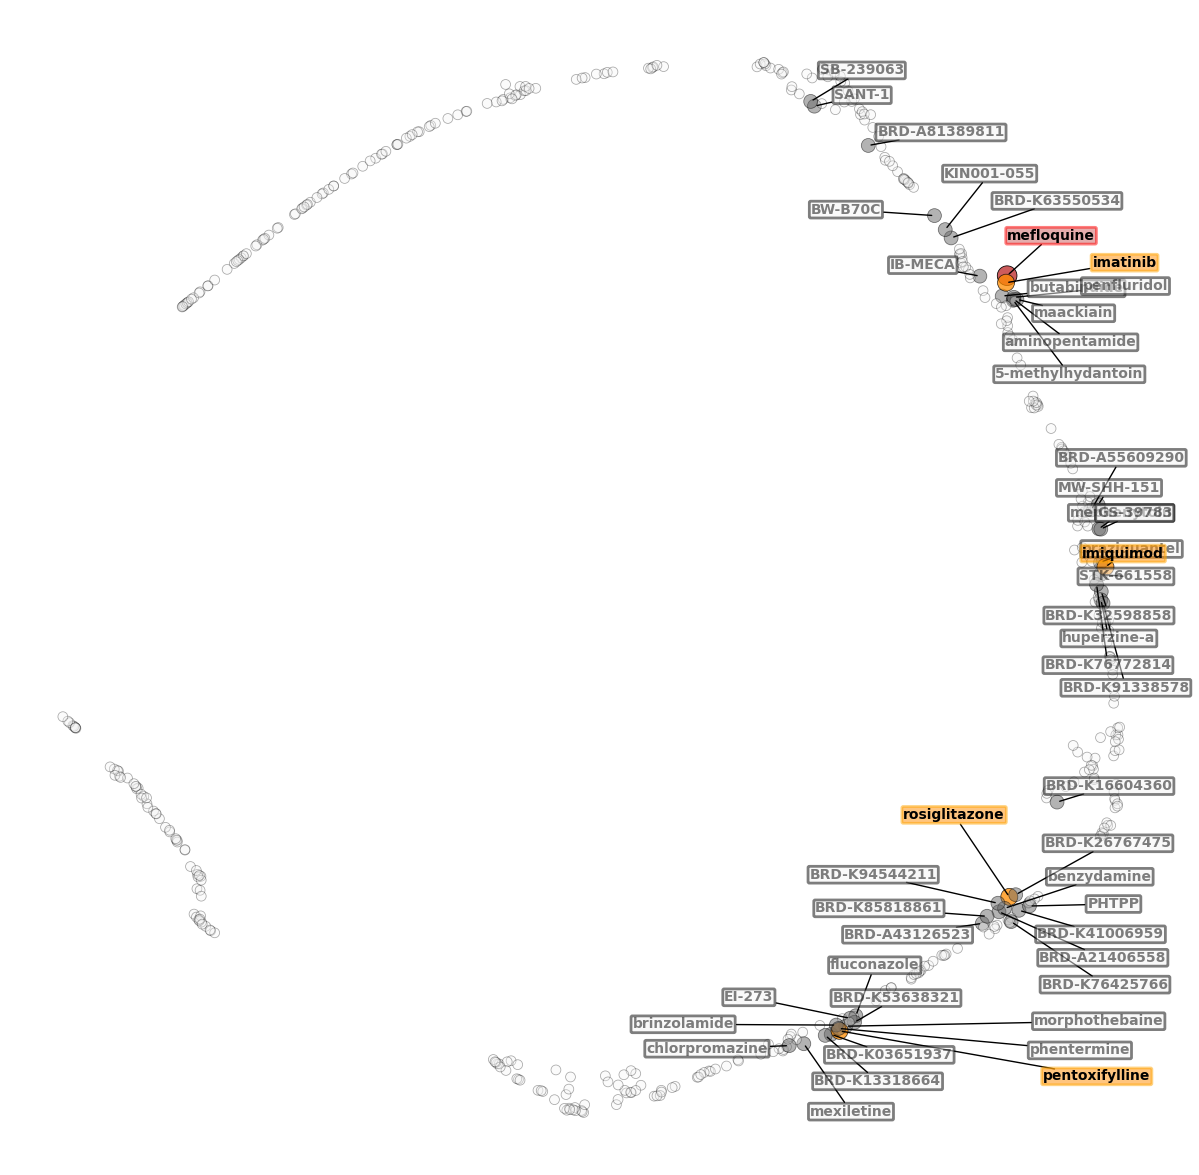

In [72]:
# Initialise list
list_highlight = []

# Iterate through df_centered
for ref_id in pd.unique(df_centered['ref_id']):
    # Slice dataframe
    df_slice = df_centered[df_centered['ref_id'] == ref_id]
    # Sort values
    df_slice.sort_values(by = 'value', ascending = False, inplace = True)
    # Get top 10 closest
    list_slice_highlight = df_slice['perturbagen_id'].iloc[1:11].tolist()
    # Add to list_highlight
    list_highlight.extend(list_slice_highlight)

# Set node colors
colors = ['indianred' if g.name == mefloquine_id else 'darkorange' if g.name in list_known_ids else 'dimgrey' if g.name in list_highlight else 'whitesmoke' for g in pyg_graphs]
# Set node sizes
sizes = [200 if g.name == mefloquine_id else 150 if g.name in list_known_ids else 100 if g.name in list_highlight else 50 for g in pyg_graphs]
# Set node alpha
alphas = [1 if g.name == mefloquine_id else 0.75 if g.name in list_known_ids else 0.5 if g.name in list_highlight else 0.33 for g in pyg_graphs]

# Plot
plt.figure(figsize=(15, 15))
plt.axis('off')
sns.scatterplot(df_plot, x = 'x', y = 'y', c = colors, edgecolors = 'black', s = sizes, alpha = alphas);

# Label styling
mefloquine_style = {'fontsize': 10, 
                    'weight' : 'bold',
                    'color': 'black',
                    'bbox': {'facecolor': 'indianred',
                             'alpha': 0.5,
                             'edgecolor': 'red',
                             'linewidth' : 2,
                             'boxstyle': 'round,pad=0.1'}}

malarial_style = {'fontsize': 10, 
                  'weight' : 'bold',
                  'color': 'black',
                  'bbox': {'facecolor': 'darkorange',
                           'alpha': 0.5,
                           'edgecolor': 'orange',
                           'linewidth' : 2,
                           'boxstyle': 'round,pad=0.1'}}

highlight_style = {'fontsize': 10, 
                   'weight' : 'bold',
                   'color': 'black',
                   'alpha' : 0.5,
                   'bbox': {'facecolor': 'whitesmoke',
                            'alpha': 0.5,
                            'edgecolor': 'black',
                            'linewidth' : 2,
                            'boxstyle': 'round,pad=0.1'}}

# Intialise list
highlight_texts = []

# Iterate through perturbagen IDs
for id in pd.unique(df_plot['perturbagen_id']):
    # Slice dataframe
    df_slice = df_plot[df_plot['perturbagen_id'] == id]
    # Get coordinates
    x, y = df_slice['x'].values[0], df_slice['y'].values[0]
    # Get label
    label = df_slice['perturbagen_name'].values[0]
    # Check if mefloquine
    if id == mefloquine_id:
        # Add coordinates, label and stlying data
        highlight_texts.append(plt.text(x, y, label, **mefloquine_style));
    # Check if anti-malarial
    elif id in list_known_ids:
        # Add coordinates, label and stlying data
        highlight_texts.append(plt.text(x, y, label, **malarial_style));
    # Check if in top 10 closest drugs
    elif id in list_highlight:
        # Add coordinates, label and stlying data
        highlight_texts.append(plt.text(x, y, label, **highlight_style));

# Adjust labels
adjust_text(highlight_texts,
            arrowprops=dict(arrowstyle='-', color='black', lw = 1),
            expand = (1.75,1.75));

# Show plot
plt.show()

## 1.5 Clustering

HDBscan package used to identify relevant clusters. 

For each cluster, a representative drug was selected by calculating the centroid point for the cluster, and finding the drug with coordinates closest to it.

In [111]:
# Initialise clustering
clusterer = hdbscan.HDBSCAN(min_cluster_size=20)
# Get cluster labels
labels = clusterer.fit_predict(embedding_2d)

# Initialise dataframe
df_cluster = df_plot.copy()
df_cluster['cluster'] = labels

# Report number of clusters identified
num_clusters = len(pd.unique(df_cluster['cluster']))
print(f'{num_clusters} clusters identified')

# Show data
df_cluster.head()

8 clusters identified


c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,x,y,perturbagen_id,perturbagen_name,cluster
0,10.606697,10.485382,BRD-A00474148,BRD-A00474148,3
1,12.513202,5.948812,BRD-A01593789,chlormadinone-acetate,6
2,7.809190,14.265384,BRD-A01826957,xanthinol,4
3,12.502592,5.497871,BRD-A02006392,nitrendipine,6
4,8.276833,14.160019,BRD-A04706586,bucladesine,4


In [112]:
# Initialise list
representatives = []

# Iterate through identified clusteres
for label, cluster in df_cluster.groupby('cluster'):
    # Check for labels > -1 (points designated as 'noise')
    if label > -1:
        # Get cluster centroid
        centroid = cluster[['x', 'y']].mean().values
        # Calculate distances of each drug in cluster to centroid
        distances = np.linalg.norm(cluster[['x', 'y']].values - centroid, axis=1)
        # Get closest drug
        closest_drug = cluster.index[np.argmin(distances)]
        # Append to list
        representatives.append(df_cluster.loc[closest_drug])
    
# Convert to dataframe
df_representatives = pd.DataFrame(representatives)
# Show data
df_representatives.head()

,x,y,perturbagen_id,perturbagen_name,cluster
156,-1.866074,-0.729690,BRD-K11927976,ER-27319,0
422,1.343974,12.512121,BRD-K78122587,NNC-55-0396,1
413,7.590712,-5.038637,BRD-K75615183,talipexole,2
163,10.956581,9.934346,BRD-K14550461,doxercalciferol,3
473,8.427463,13.650561,BRD-K91442916,CAM-9-026,4


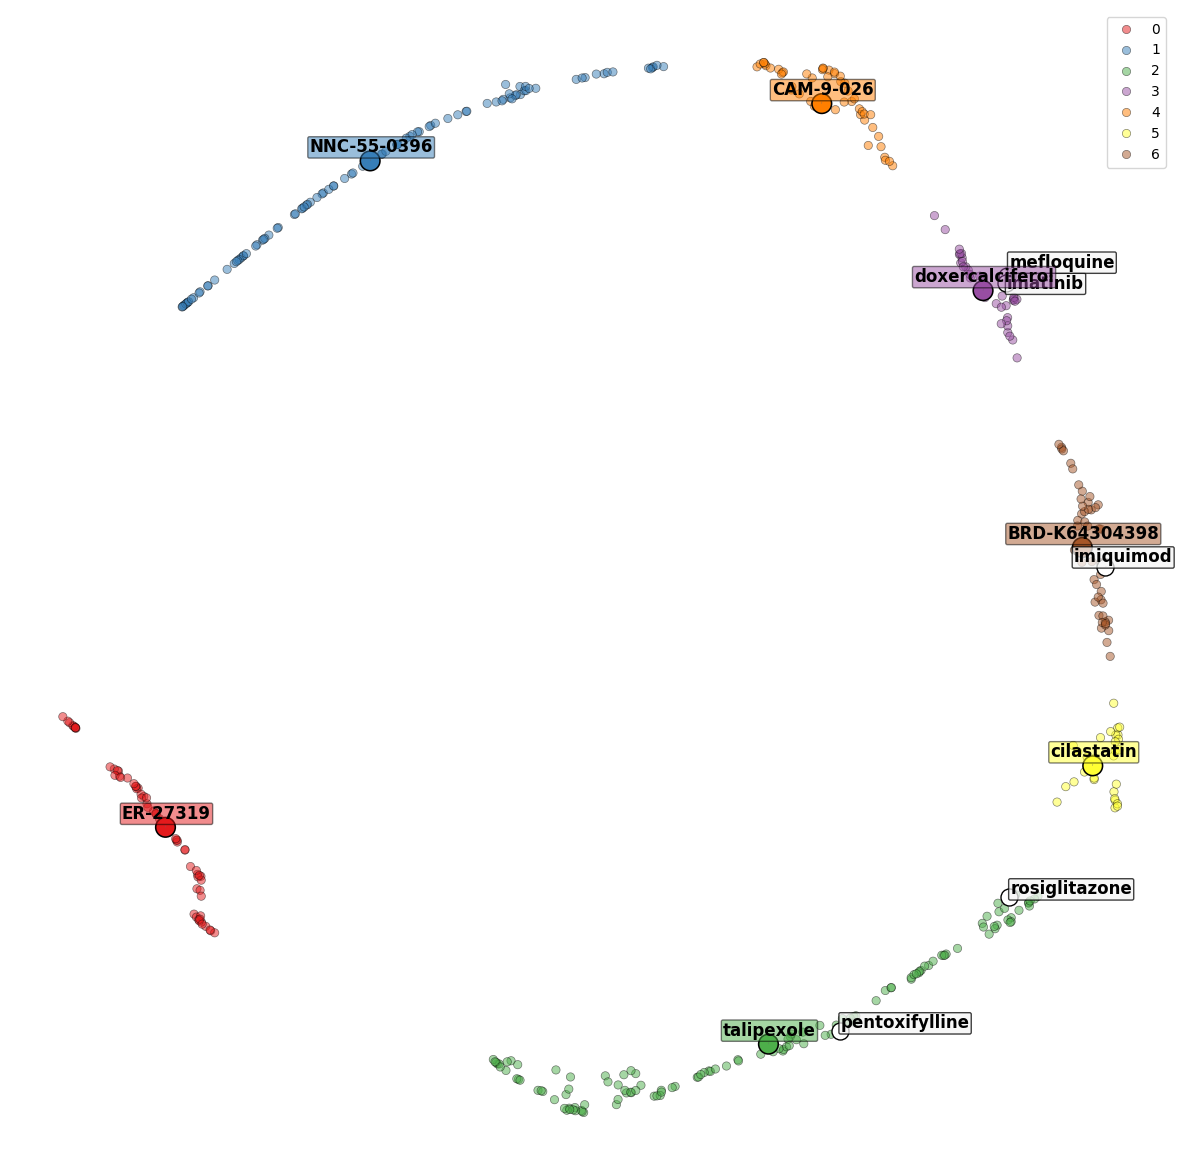

In [113]:
# Plot
plt.figure(figsize = (15,15))
plt.axis('off')

# Plot clusters
sns.scatterplot(df_cluster[df_cluster['cluster'] != -1], 
                x = 'x', y = 'y', 
                hue = 'cluster', palette = 'Set1', 
                alpha = 0.5, edgecolors = 'black')
# Plot representative points
sns.scatterplot(df_representatives, 
                x = 'x', y = 'y', 
                hue = 'cluster', palette = 'Set1', 
                edgecolors = 'black', s = 200, legend = False)
# Plot known anti-malarials
sns.scatterplot(df_cluster[df_cluster['perturbagen_id'].isin(list_known_ids)], 
                x = 'x', y = 'y', 
                c = 'white', s = 150, alpha = 1, edgecolors = 'black')

# Set label styling
malarial_style = {'fontsize': 12,
                  'alpha' : 1,
                  'weight' : 'bold',
                  'color': 'black',
                  'bbox': {'facecolor': 'whitesmoke',
                           'alpha': 0.75,
                           'edgecolor': 'black',
                           'boxstyle': 'round,pad=0.1'}}

# Initialise text label list
texts = []

# Iterate through anti-malarial IDs
for id in list_known_ids:
    # Slice dataframe
    df_slice = df_cluster[df_cluster['perturbagen_id'] == id]
    # Get coordinates
    x, y = df_slice['x'].values[0], df_slice['y'].values[0]
    # Get label
    label = df_slice['perturbagen_name'].values[0]
    # Append with styling
    texts.append(plt.text(x, y, label, **malarial_style));

# Adjust labels
adjust_text(texts,
            arrowprops=dict(arrowstyle='-', color='dimgrey', lw = 0.25),
            expand = (1,1));

# Initialise representative text label list
rep_texts = []

# Get first n colours from Set1 palette
n = 10
palette_colors = list(sns.color_palette('Set1', n_colors=n))

# Iterate through representative drug IDs and palette colours
for id, colour in zip(pd.unique(df_representatives['perturbagen_id']), palette_colors):
    # Slice dataframe
    df_slice = df_representatives[df_representatives['perturbagen_id'] == id]
    # Get coordinates
    x, y = df_slice['x'].values[0], df_slice['y'].values[0]
    # Get label
    label = df_slice['perturbagen_name'].values[0]

    # Set label styling
    rep_style = {'fontsize': 12,
                 'alpha' : 1,
                 'weight' : 'bold',
                 'color': 'black',
                 'ha': 'center',             
                 'va': 'bottom',             
                 'bbox': {'facecolor': colour,
                          'alpha': 0.5,
                          'edgecolor': 'black',
                          'boxstyle': 'round,pad=0.1'}}

    # Append with styling
    rep_texts.append(plt.text(x, y, label, **rep_style))

# Adjust text labels
adjust_text(rep_texts,
            arrowprops=dict(arrowstyle='-', color='dimgrey', lw = 0.25));

# Show plot
plt.show()